In [408]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

In [409]:
df_sales = pd.read_csv('./datasets/sales_data.csv')

In [410]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tempo_de_experiencia  100 non-null    int64  
 1   numero_de_vendas      100 non-null    int64  
 2   fator_sazonal         100 non-null    int64  
 3   receita_em_reais      100 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 3.3 KB


In [411]:
df_sales.head(3)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais
0,36,21,5,2639.886941
1,74,44,10,4707.322227
2,38,44,4,5910.035131


In [412]:
df_sales.describe()

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais
count,100.000000,100.000000,100.000000,100.000000
mean,64.490000,54.490000,5.820000,5112.941924
std,32.397935,25.307201,2.836914,2544.731052
min,1.000000,10.000000,1.000000,1133.363948
25%,38.750000,37.500000,4.000000,2800.660516
50%,64.500000,52.500000,5.000000,4953.770034
75%,93.000000,70.500000,8.000000,7079.500163
max,119.000000,100.000000,10.000000,9941.016458


In [413]:
df_sales_eda = df_sales.copy()

df_sales_bucketing = df_sales.copy()

### EDA - Ánalise Exploratoria de Dados

<Axes: xlabel='tempo_de_experiencia'>

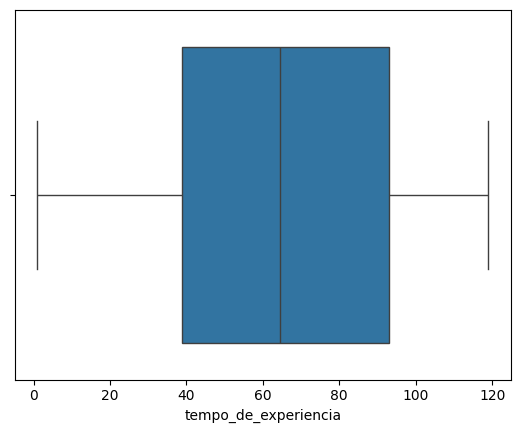

In [414]:
sns.boxplot(df_sales_eda, x='tempo_de_experiencia')

<Axes: xlabel='numero_de_vendas'>

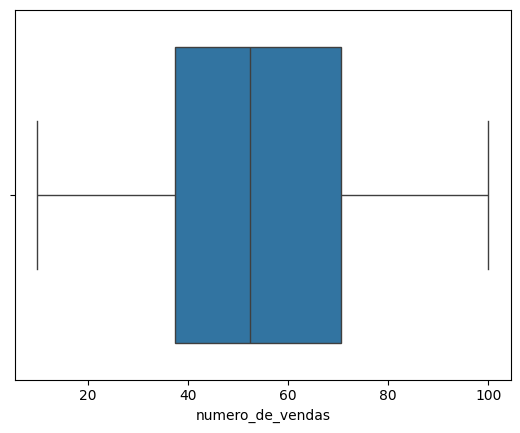

In [415]:
sns.boxplot(df_sales_eda, x='numero_de_vendas')

<Axes: xlabel='fator_sazonal'>

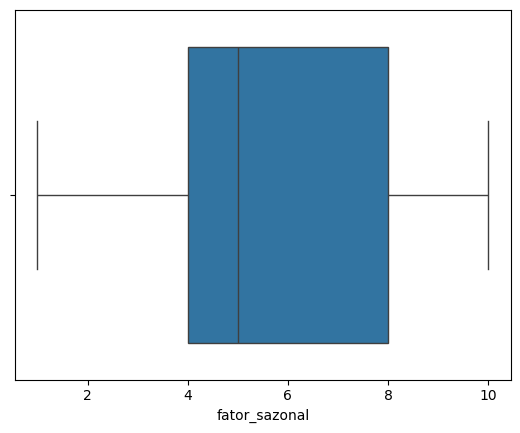

In [416]:
sns.boxplot(df_sales_eda, x='fator_sazonal')


<Axes: xlabel='tempo_de_experiencia', ylabel='receita_em_reais'>

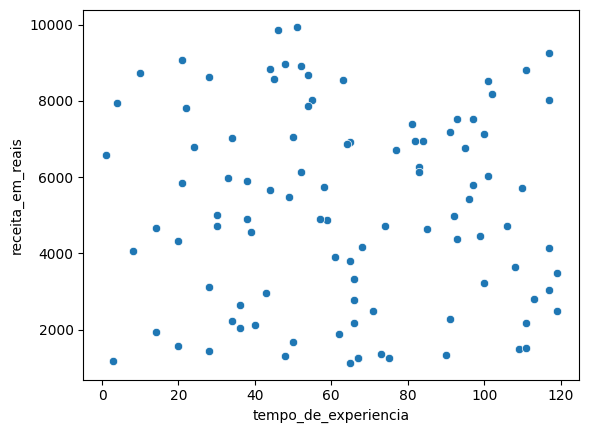

In [417]:
sns.scatterplot(df_sales_eda, x='tempo_de_experiencia', y='receita_em_reais')


<Axes: xlabel='numero_de_vendas', ylabel='receita_em_reais'>

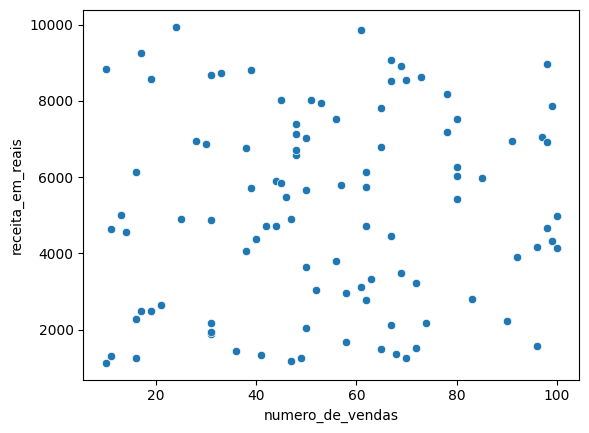

In [418]:
sns.scatterplot(df_sales_eda, x='numero_de_vendas', y='receita_em_reais')


<Axes: xlabel='fator_sazonal', ylabel='receita_em_reais'>

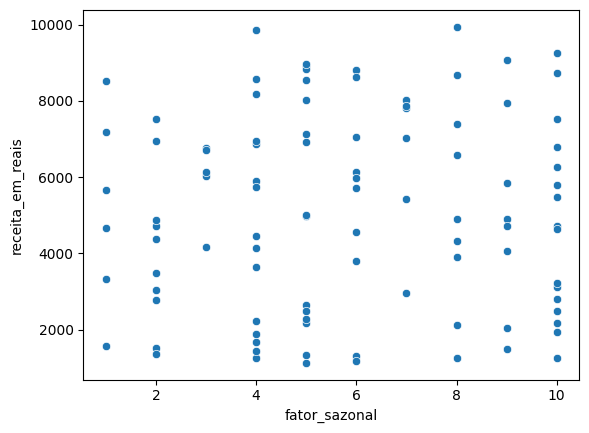

In [419]:
sns.scatterplot(df_sales_eda, x='fator_sazonal', y='receita_em_reais')


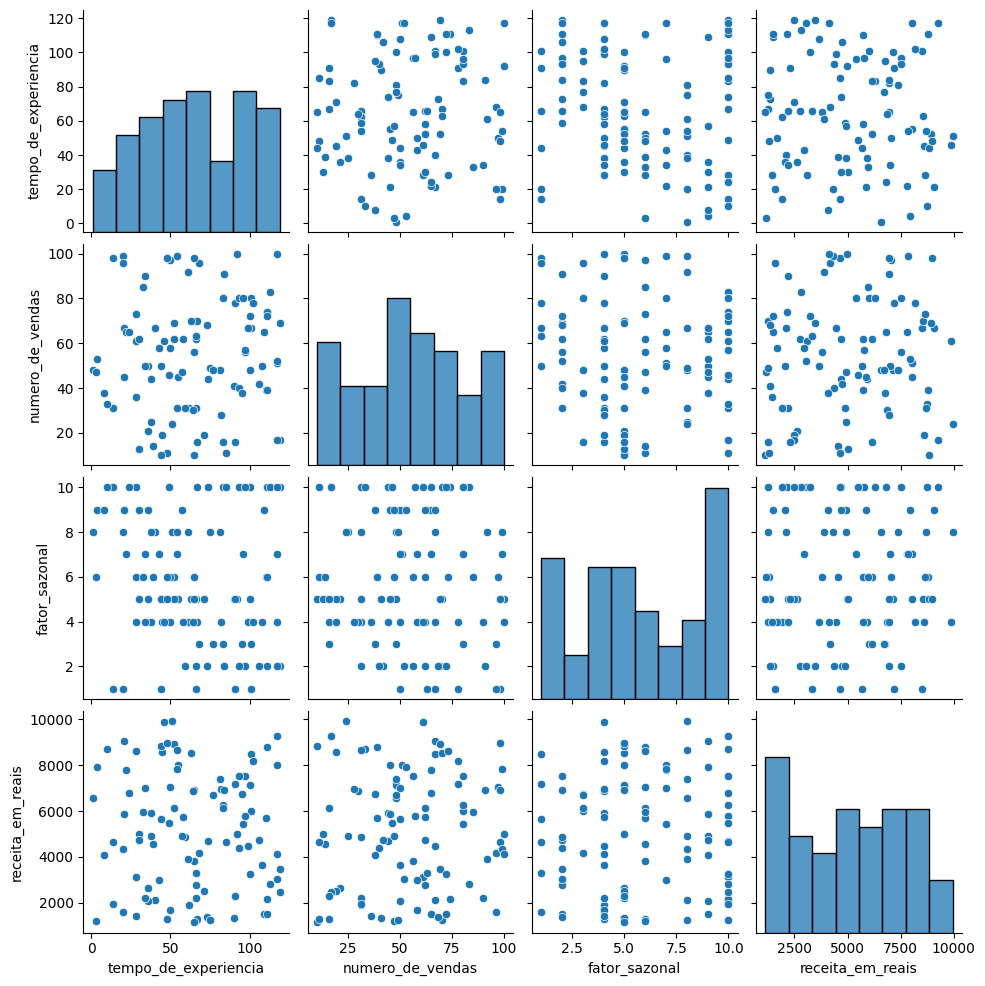

In [420]:
sns.pairplot(df_sales_eda)

### Analise de Correlacao

<Axes: >

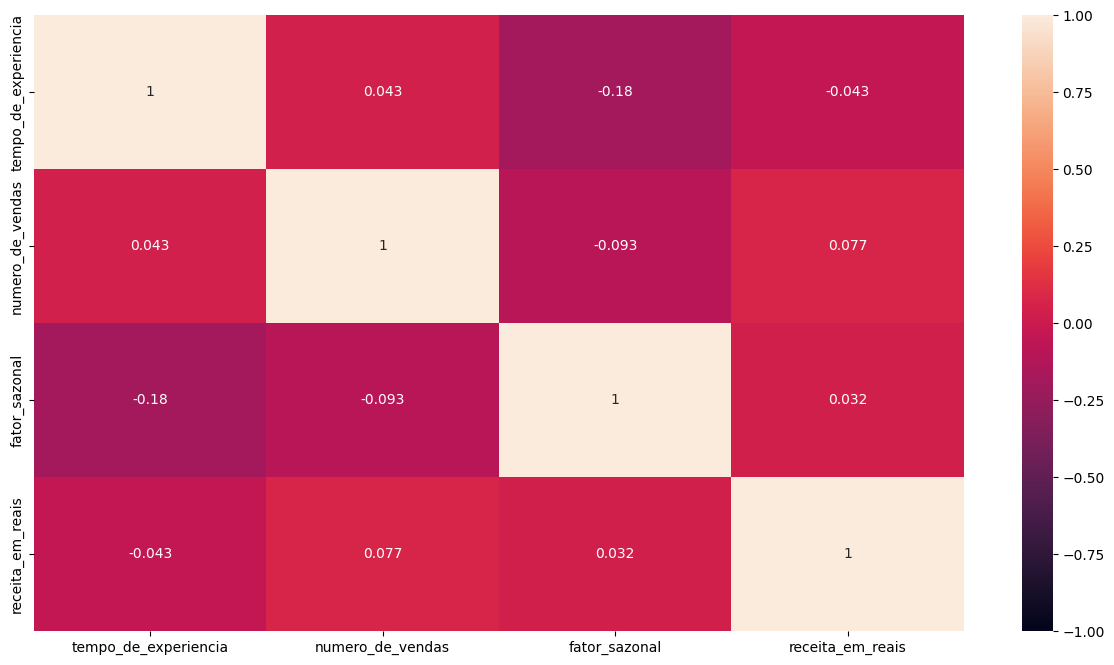

In [421]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_sales_eda.corr(), vmax=1, vmin=-1, annot=True)

<Axes: >

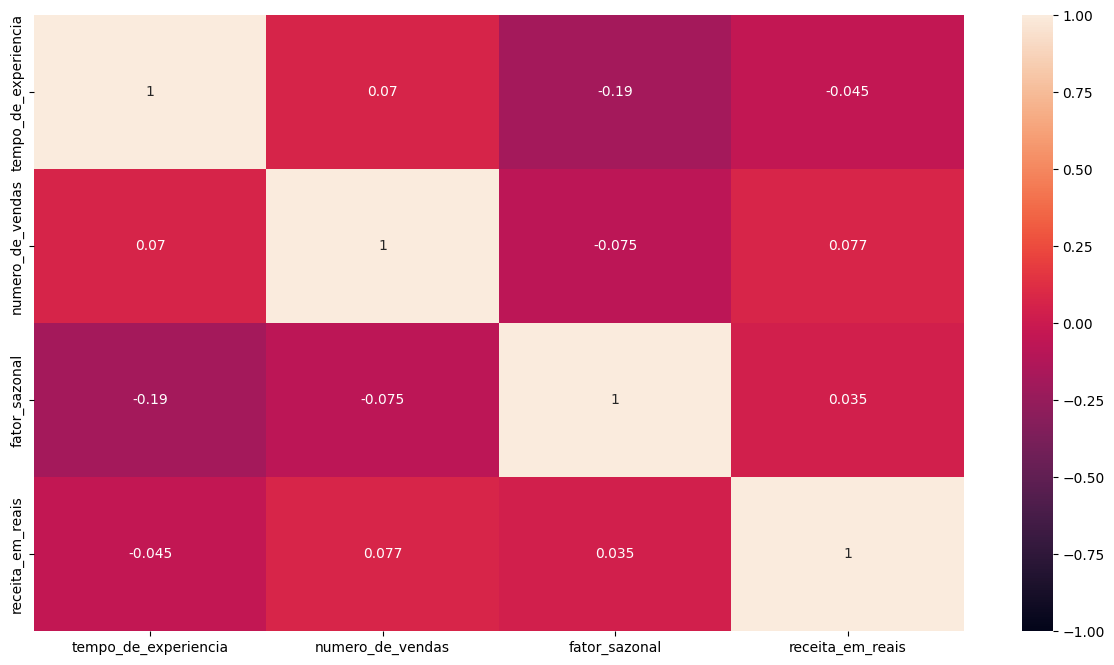

In [422]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_sales_eda.corr('spearman'), vmax=1, vmin=-1, annot=True)

<Axes: >

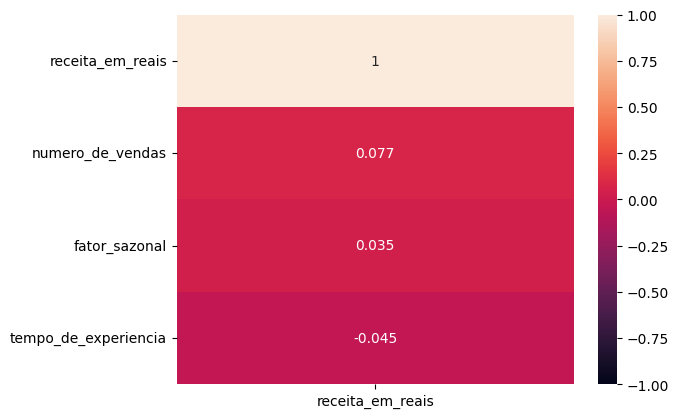

In [423]:

sns.heatmap(df_sales_eda.corr('spearman')[['receita_em_reais']].sort_values(by='receita_em_reais', ascending=False), vmax=1, vmin=-1, annot=True)

### Analise Bucketing

In [424]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140]
labels = ['0-9', '10-19', '20-29', '30-39' ,'40-49','50-59','60-69','70-79','80-89','90-99','100-109','110-119',
          '120-129','130-139']


df_sales_bucketing['escala_tempo_de_experiencia']= pd.cut(df_sales_bucketing['tempo_de_experiencia'], bins=bins, labels=labels, include_lowest=True)



In [425]:
df_sales_bucketing.head(3)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais,escala_tempo_de_experiencia
0,36,21,5,2639.886941,30-39
1,74,44,10,4707.322227,70-79
2,38,44,4,5910.035131,30-39


<Axes: xlabel='escala_tempo_de_experiencia', ylabel='receita_em_reais'>

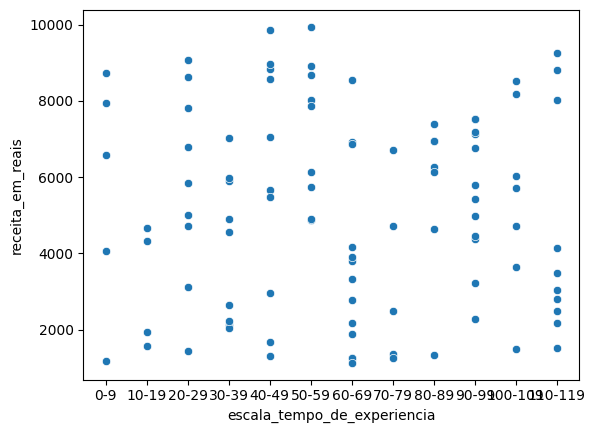

In [426]:
sns.scatterplot(df_sales_bucketing, x='escala_tempo_de_experiencia', y='receita_em_reais')

In [427]:

df_sales_bucketing['escala_numero_de_vendas']= pd.cut(df_sales_bucketing['numero_de_vendas'], bins=bins, labels=labels, include_lowest=True)



In [428]:
df_sales_bucketing.head(3)

,tempo_de_experiencia,numero_de_vendas,fator_sazonal,receita_em_reais,escala_tempo_de_experiencia,escala_numero_de_vendas
0,36,21,5,2639.886941,30-39,20-29
1,74,44,10,4707.322227,70-79,40-49
2,38,44,4,5910.035131,30-39,40-49


<Axes: xlabel='escala_numero_de_vendas', ylabel='receita_em_reais'>

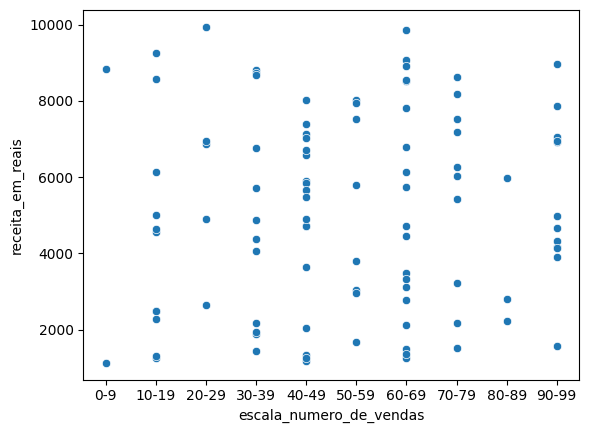

In [429]:
sns.scatterplot(df_sales_bucketing, x='escala_numero_de_vendas', y='receita_em_reais')

### Treinar Modelo - Regressão Linear


In [430]:
X = df_sales.drop(columns=['receita_em_reais'])
y = df_sales['receita_em_reais']



In [431]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2, random_state=42 )

In [432]:
X_train.shape

(80, 3)

In [433]:
X_test.shape

(20, 3)

In [434]:
colunas_numericas = ['tempo_de_experiencia', 'numero_de_vendas', 'fator_sazonal'] 



transform_numericas = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')), 
        ('scaler', StandardScaler())
    ]
)

In [435]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num' , transform_numericas, colunas_numericas)
    ]
)

In [436]:

model_regr = Pipeline(
    steps=[
        # ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

In [437]:
model_regr.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Analises de Resultado

In [438]:
y_pred = model_regr.predict(X_test)

y_pred_linear = y_pred

In [439]:
y_pred

array([5243.18792752, 5409.9930733 , 5460.5466346 , 5160.55027121,
       5436.66973595, 5190.08286652, 4855.1896125 , 5344.30940602,
       5406.64594225, 4918.92796435, 5181.77768872, 5011.59530647,
       4956.34764289, 5455.46189459, 5269.60064569, 4668.50269616,
       5450.65280641, 5294.82451557, 5425.75030462, 4761.55416019])

### Analise de Metricas

In [440]:
# Calcular R2 Score
# Obs: Quanto mais proximo de 1 melhor
r2_score(y_test, y_pred)

-0.06596934817736

In [441]:
mean_absolute_error(y_test, y_pred)

1864.356071200246

In [442]:
root_mean_squared_error(y_test, y_pred)

2199.7828451156333

In [443]:
mean_squared_error(y_test, y_pred)

4839044.565665031

### Residuos

In [444]:
residuos = y_test - y_pred

In [445]:
from scipy.stats import zscore


In [446]:
residuos_std = zscore(residuos)

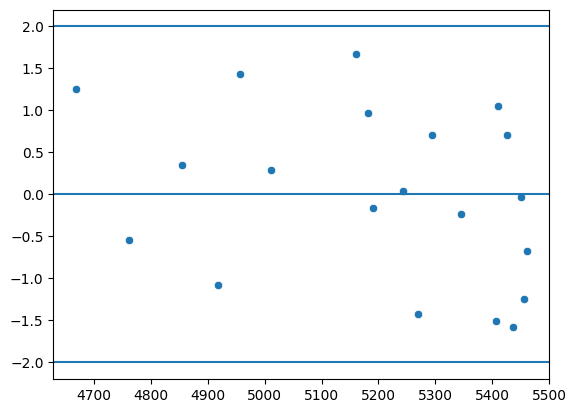

In [447]:
sns.scatterplot(x=y_pred, y=residuos_std)
plt.axhline(y=0)
plt.axhline(y=2)
plt.axhline(y=-2)

In [448]:
import pingouin as pg

Text(0, 0.5, 'Residuos na escala padrao')

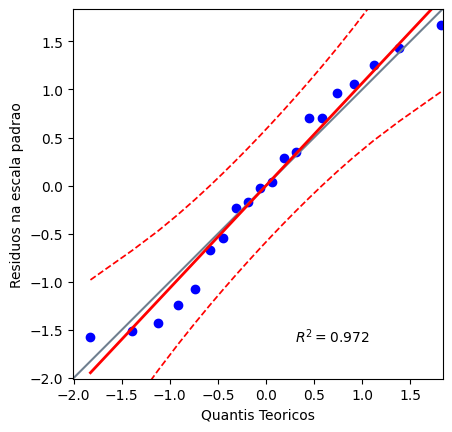

In [449]:

pg.qqplot(residuos_std, dist='norm', confidence=0.95)
plt.xlabel("Quantis Teoricos")
plt.ylabel("Residuos na escala padrao")

###  Modelo Polinomial

In [450]:
X = df_sales.drop(columns=['receita_em_reais'])
y = df_sales['receita_em_reais']




In [451]:
from sklearn.model_selection import KFold
import numpy as np

In [452]:


# graus_polynomial = [1, 2, 3, 4]
graus_polynomial = [2]

rmse_train_values = []
rmse_test_values = []
r2score_values = []
residuos_values = []
y_pred_poly_total = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [453]:
kf.split(X)

<generator object _BaseKFold.split at 0x000002B324415030>

In [454]:
for grau in graus_polynomial:
    
    colunas_numericas = ['tempo_de_experiencia', 'numero_de_vendas', 'fator_sazonal'] 

    transform_numericas = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler())
        ]
    )

    poly_feat =  PolynomialFeatures(degree=grau, include_bias=False)

    preprocessor = ColumnTransformer(
    transformers=[
        ('num' , transform_numericas, colunas_numericas)
    ])

    model_poly = Pipeline(
        steps=[
            # ('preprocessor', preprocessor),
            ('poly_features', poly_feat),
            ('regressor', LinearRegression())
        ]
    )

    
    rmse_train_colet = []
    rmse_test_colet = []
    r2score_colet = []
    residuos_colet = []
    y_pred_poly_total = []
    y_test_poly =[]

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model_poly.fit(X_train, y_train)

        y_train_pred = model_poly.predict(X_train)

        y_test_pred = model_poly.predict(X_test)

        rmse_train = root_mean_squared_error(y_train, y_train_pred)
        rmse_train_colet.append(rmse_train)

        rmse_test = root_mean_squared_error(y_test, y_test_pred)
        rmse_test_colet.append(rmse_test)

        r2score_test = r2_score(y_test, y_test_pred)
        r2score_colet.append(r2score_test)

        residuos_test = np.array(y_test - y_test_pred)
        residuos_colet.append(residuos_test)
        y_pred_poly_total.append(y_test_pred)
        y_test_poly.append(y_test)


    rmse_train_values.append(np.mean(rmse_train_colet))
    rmse_test_values.append(np.mean(rmse_test_colet))
    r2score_values.append(np.mean(r2score_colet))

    residuos_values = np.array(residuos_colet).reshape(-1)

    y_pred_poly_total = np.array(y_pred_poly_total).reshape(-1)
    y_test_poly = np.array(y_test_poly).reshape(-1)


    



        





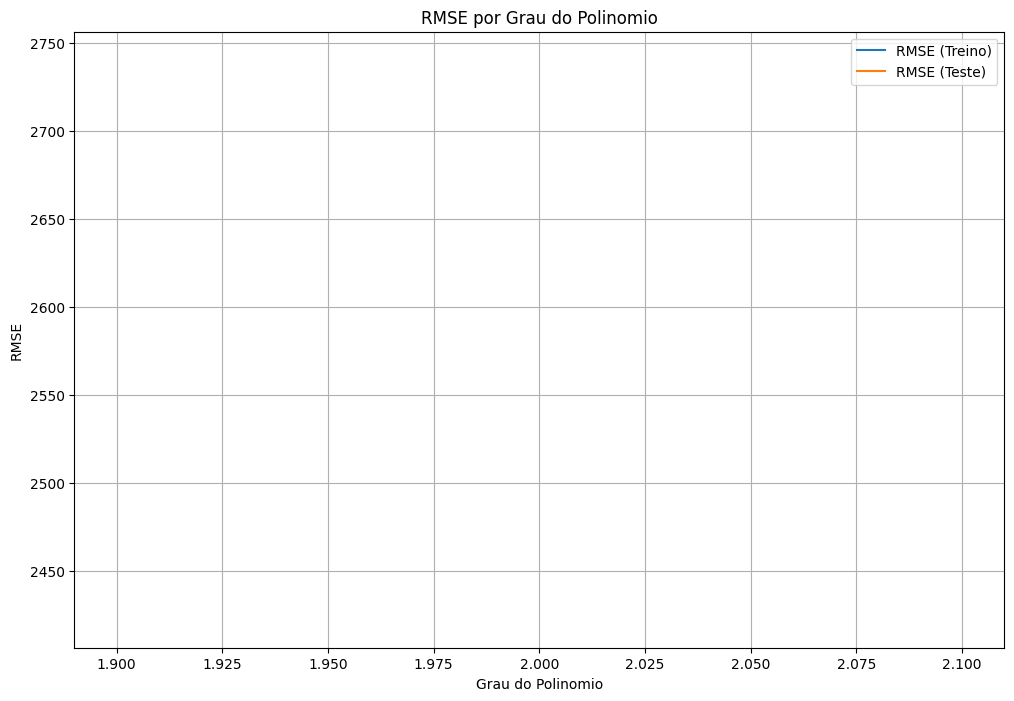

In [455]:
plt.figure(figsize=(12, 8))
plt.plot(graus_polynomial, rmse_train_values, label='RMSE (Treino)')
plt.plot(graus_polynomial, rmse_test_values, label='RMSE (Teste)')
plt.xlabel("Grau do Polinomio")
plt.ylabel("RMSE")
plt.title("RMSE por Grau do Polinomio")
plt.legend()
plt.grid(True)
plt.show()




### Analise de Metricas - Polinomio de Grau 2


In [456]:
# Métricas 
print(f'RMSE Treino: {rmse_train_values[0]}')
print(f'RMSE Teste: {rmse_test_values[0]}')
print(f'R2Score Teste: {r2score_values[0]}')



RMSE Treino: 2422.517203215722
RMSE Teste: 2740.6763430175865
R2Score Teste: -0.2944232033409481


In [457]:
residuos_std = zscore(residuos_values)

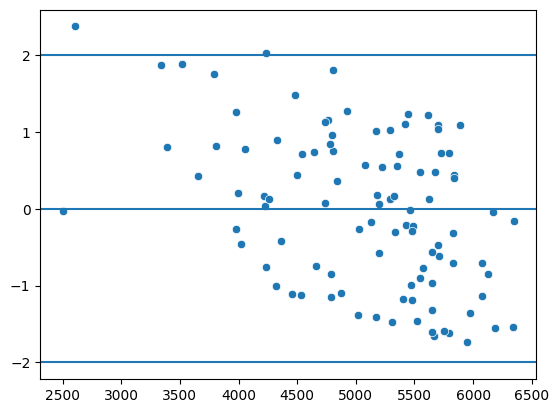

In [458]:
sns.scatterplot(x=y_pred_poly_total, y=residuos_std)
plt.axhline(y=0)
plt.axhline(y=2)
plt.axhline(y=-2)

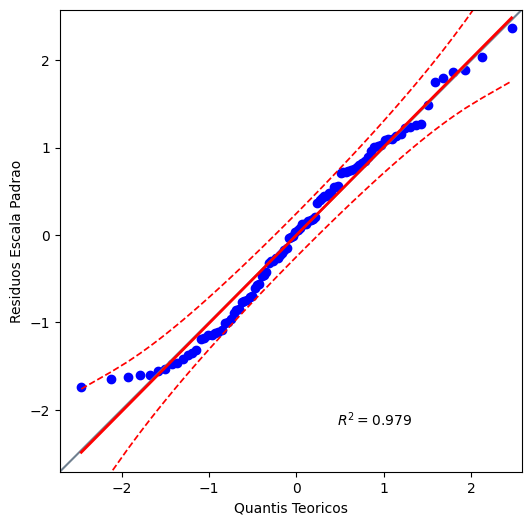

In [459]:
import pingouin as pg

plt.figure(figsize=(15,6))
pg.qqplot(x=residuos_values, dist='norm', confidence=0.95)
plt.xlabel('Quantis Teoricos')
plt.ylabel('Residuos Escala Padrao')
plt.show()

### Teste de Homoscedasticidade
 Analisamos os resíduos do modelo polinomial e comparamos com a regressão linear. Observamos que o modelo polinomial apresentou melhorias significativas em termos de linearidade e homoscedasticidade. Também realizamos o teste de distribuição normal nos resíduos e constatamos que eles seguem uma distribuição normal, ao contrário do modelo de regressão linear. Utilizamos diferentes testes, como Shapiro-Wilk e Kolmogorov-Smirnov, e concluímos que os resíduos do modelo polinomial se ajustam melhor aos dados. Ao final da aula, resumimos que o modelo polinomial, com suas features polinomiais, apresentou métricas e análise de resíduos superiores ao modelo linear. Nos próximos vídeos, abordarem

In [460]:
# Teste de Shapiro-Wild

from scipy.stats import shapiro, kstest
from statsmodels.stats.diagnostic import lilliefors

stat_shapiro, p_value_shapiro = shapiro(residuos)

print(f'Estat, Teste {stat_shapiro} e P-Value {p_value_shapiro}')


Estat, Teste 0.9528157863127623 e P-Value 0.4118628325207934


In [461]:
# Teste de Komogorov-Smirrnov

stat_ks, p_value_ks = kstest(residuos, 'norm')

print(f'Estat. Teste {stat_ks} e P-Value {p_value_ks}')



Estat. Teste 0.55 e P-Value 3.286197066228009e-06


In [462]:
# Teste de lilliefors

stat_li, p_value_li = lilliefors(residuos, 'norm', pvalmethod='table')

print(f'Estat. Teste {stat_li} e P-Value {p_value_li}')


Estat. Teste 0.10381167728947294 e P-Value 0.8160000621932919


### Predição

In [463]:
### Testar

# Valores para previsão (substitua pelos valores do vendedor específico)

input_features = {
    'tempo_de_experiencia' : 37,
    'numero_de_vendas' : 29,
    'fator_sazonal' : 5,
}

pred_df = pd.DataFrame(input_features, index=[1])




In [464]:
model_poly.predict(pred_df)

array([5041.55057185])

In [465]:
model_regr.predict(pred_df)

array([4965.05129851])